In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import zarr
from diffusion_policy.common.replay_buffer import ReplayBuffer
from omegaconf import OmegaConf
from diffusion_policy.codecs.imagecodecs_numcodecs import register_codecs
from umi.common.pose_util import (
    pose_to_mat, mat_to_pose, 
    mat_to_pose10d, pose10d_to_mat)
from diffusion_policy.common.pose_repr_util import convert_pose_mat_rep



In [2]:
OmegaConf.register_new_resolver("eval", eval, replace=True)
register_codecs()

In [3]:
zarr_path = '/home/jaco/dataset.zarr.zip'
zip_store = zarr.ZipStore(zarr_path, mode='a')
root = zarr.group(zip_store)
replay_buffer = ReplayBuffer.create_from_group(root)
num_episodes = len(replay_buffer.episode_ends)
print(f"Loaded replay buffer with {num_episodes} episodes.")
episode_idx = np.random.choice(num_episodes)
print(f"Replaying episode {episode_idx}...")
ep = replay_buffer.get_episode(episode_idx)
# print(ep.keys()) 
# dict_keys(['camera0_rgb', 'robot0_demo_end_pose', 'robot0_demo_start_pose', 
# 'robot0_eef_pos', 'robot0_eef_rot_axis_angle', 
# 'robot0_force', 'robot0_gripper_width', 'robot0_torque'])
for robot_idx in range(1):
    pos_replay = ep[f'robot{robot_idx}_eef_pos'][:]
    rot_replay = ep[f'robot{robot_idx}_eef_rot_axis_angle'][:]
    grip_replay = ep[f'robot{robot_idx}_gripper_width'][:]
actions = np.concatenate([pos_replay, rot_replay, grip_replay], axis=-1)

Loaded replay buffer with 205 episodes.
Replaying episode 89...


In [4]:
# action processing
pose_mat = pose_to_mat(np.concatenate([
    pos_replay, rot_replay
], axis = -1))
print(pose_mat.shape)
print(actions[0, 0:6])
action_mat = pose_to_mat(actions[..., 0: 6])
action_pose_mat = convert_pose_mat_rep(
                action_mat, 
                base_pose_mat=pose_mat[-1],
                pose_rep='rel',
                backward=False)
action_pose10d = mat_to_pose10d(action_pose_mat)
print(action_pose10d[0])
action_pose_mat_ = pose10d_to_mat(action_pose10d)
print(action_pose_mat[0])
action_mat = convert_pose_mat_rep(
    action_pose_mat_,
    base_pose_mat=pose_mat[-1],
    pose_rep='rel',
    backward=True
)
print(action_mat[0])
action_pose = mat_to_pose(action_mat)
print(action_pose[0])

(924, 4, 4)
[-0.0037697  -0.17308985  0.09887446 -2.1443133   0.15694277  0.07999384]
[ 0.15132819 -0.1075734   0.04589518  0.9989313   0.04577468 -0.00639728
 -0.04604672  0.99757546 -0.05218058]
[[ 0.9989313   0.04577468 -0.00639728  0.15132819]
 [-0.04604672  0.99757546 -0.05218058 -0.1075734 ]
 [ 0.00399322  0.05241939  0.9986172   0.04589518]
 [ 0.          0.          0.          1.        ]]
[[ 0.9896191  -0.14367022  0.00360072 -0.0037697 ]
 [-0.08150128 -0.5404028   0.83744997 -0.17308985]
 [-0.11837079 -0.8290499  -0.54650223  0.09887446]
 [ 0.          0.          0.          1.        ]]
[-0.0037697  -0.17308985  0.09887446 -2.1443133   0.15694277  0.07999384]


In [5]:
action_lists = pickle.load(open('/home/jaco/actions.pkl', 'rb'))

In [6]:
all_norm_actions = action_lists[0]
all_unnorm_actions = action_lists[1]
all_real_umi_actions = action_lists[2]
all_target_actions = action_lists[-1]

In [7]:
max_ep_length = len(all_unnorm_actions)
norm_action = np.zeros(shape=(max_ep_length, 4))
unnorm_action = np.zeros(shape=(max_ep_length, 4))
real_umi_action = np.zeros(shape=(max_ep_length, 4))
target_action = np.zeros(shape=(max_ep_length, 4))

for idx, action in enumerate(all_norm_actions):
    norm_action[idx, :3] = action[:3]
    norm_action[idx, -1] = action[-1]

for idx, action in enumerate(all_unnorm_actions):
    unnorm_action[idx, :3] = action[:3]
    unnorm_action[idx, -1] = action[-1]

for idx, action in enumerate(all_real_umi_actions):
    real_umi_action[idx, :3] = action[:3]
    real_umi_action[idx, -1] = action[-1]

for idx, action in enumerate(all_target_actions):
    target_action[idx, :3] = action[0][:3]
    target_action[idx, -1] = action[0][-1]

In [8]:
pos_replay = pos_replay[:max_ep_length, ...]
grip_replay = grip_replay[:max_ep_length, ...]

In [9]:
norm_action.shape

(1800, 4)

In [10]:
def plot_pos(pose_comms):
    # Extract x, y, z coordinates
    x = pose_comms[:, 0]
    y = pose_comms[:, 1]
    z = pose_comms[:, 2]

    # Generate colors based on order (index)
    colors = np.linspace(0, 1, len(x))  # Normalize order for color mapping

    # Create the 3D scatter plot
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot with gradient colors
    sc = ax.scatter(x, y, z, c=colors, cmap='cool', s=50)

    # Add labels and colorbar
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    cb = plt.colorbar(sc)
    cb.set_label('Point Order')

    plt.show()

In [11]:
def plot_width(pose_comms):
    # Extract gripper width
    x = range(pose_comms.shape[0])
    y = pose_comms[:, -1]

    # Add labels and colorbar
    plt.plot(x, y)
    plt.show()

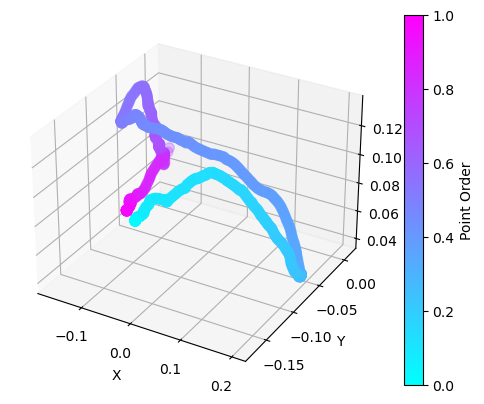

In [12]:
plot_pos(pos_replay)

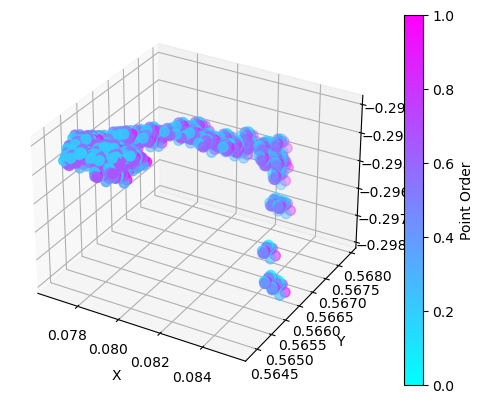

In [13]:
plot_pos(norm_action)

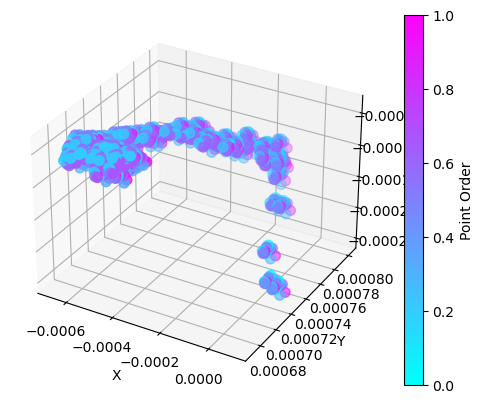

In [14]:
plot_pos(unnorm_action)

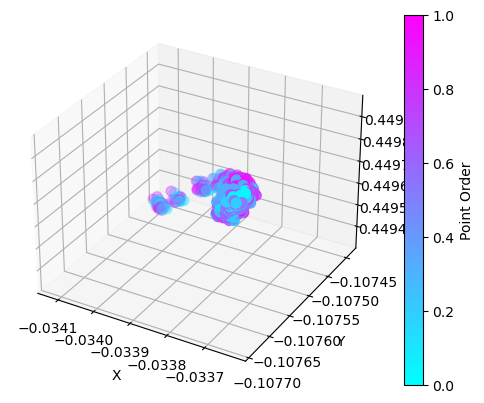

In [15]:
plot_pos(real_umi_action)

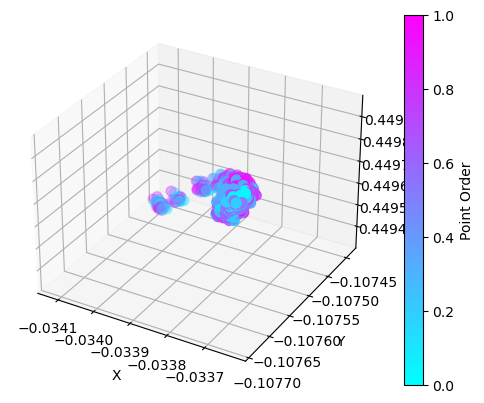

In [16]:
plot_pos(target_action)

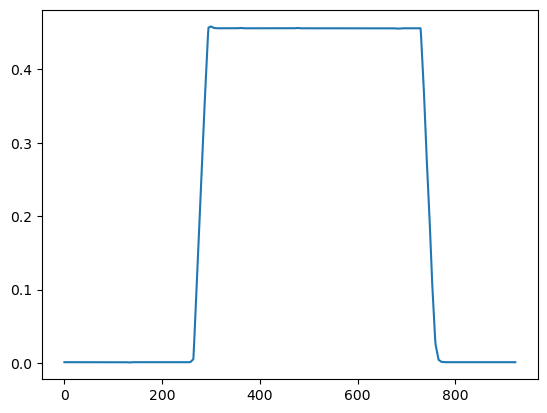

In [17]:
plot_width(grip_replay)

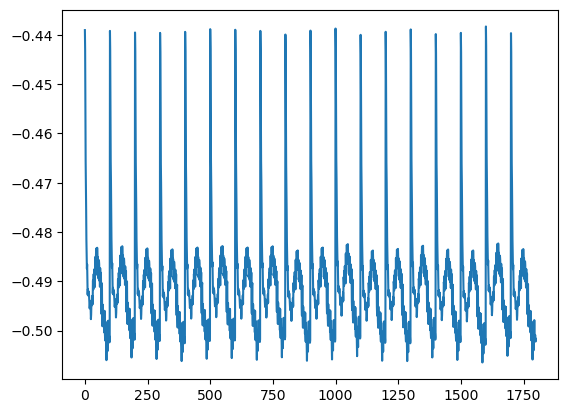

In [18]:
plot_width(norm_action)
# -0.45 ~ -0.51

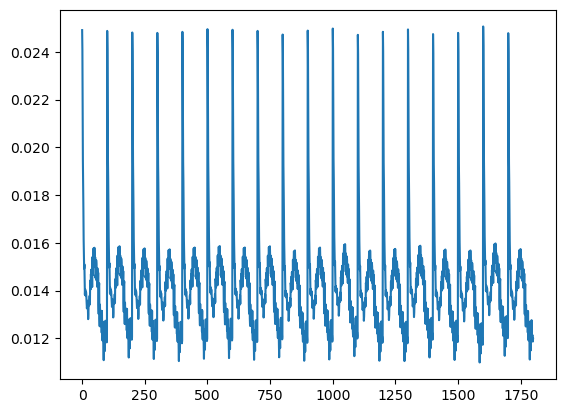

In [19]:
plot_width(unnorm_action)
# 0.024 ~ 0.010

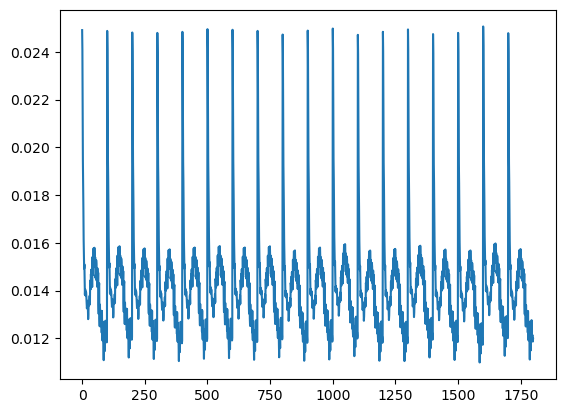

In [20]:
plot_width(real_umi_action)
# -0.45 ~ -0.51 (before)
# 0.024 ~ 0.010 (after i fixed my mistake)

In [21]:
def plot_pos_multi(ax, pose_comms, title=""):
    # Extract x, y, z coordinates
    x = pose_comms[:, 0]
    y = pose_comms[:, 1]
    z = pose_comms[:, 2]

    # Generate colors based on order (index)
    colors = np.linspace(0, 1, len(x))  # Normalize order for color mapping

    # Scatter plot with gradient colors
    sc = ax.scatter(x, y, z, c=colors, cmap='cool', s=50)

    # Add labels
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)

[ 65  94 138 179 156  39 166  10 161 160 117 125   0  68 143  89]


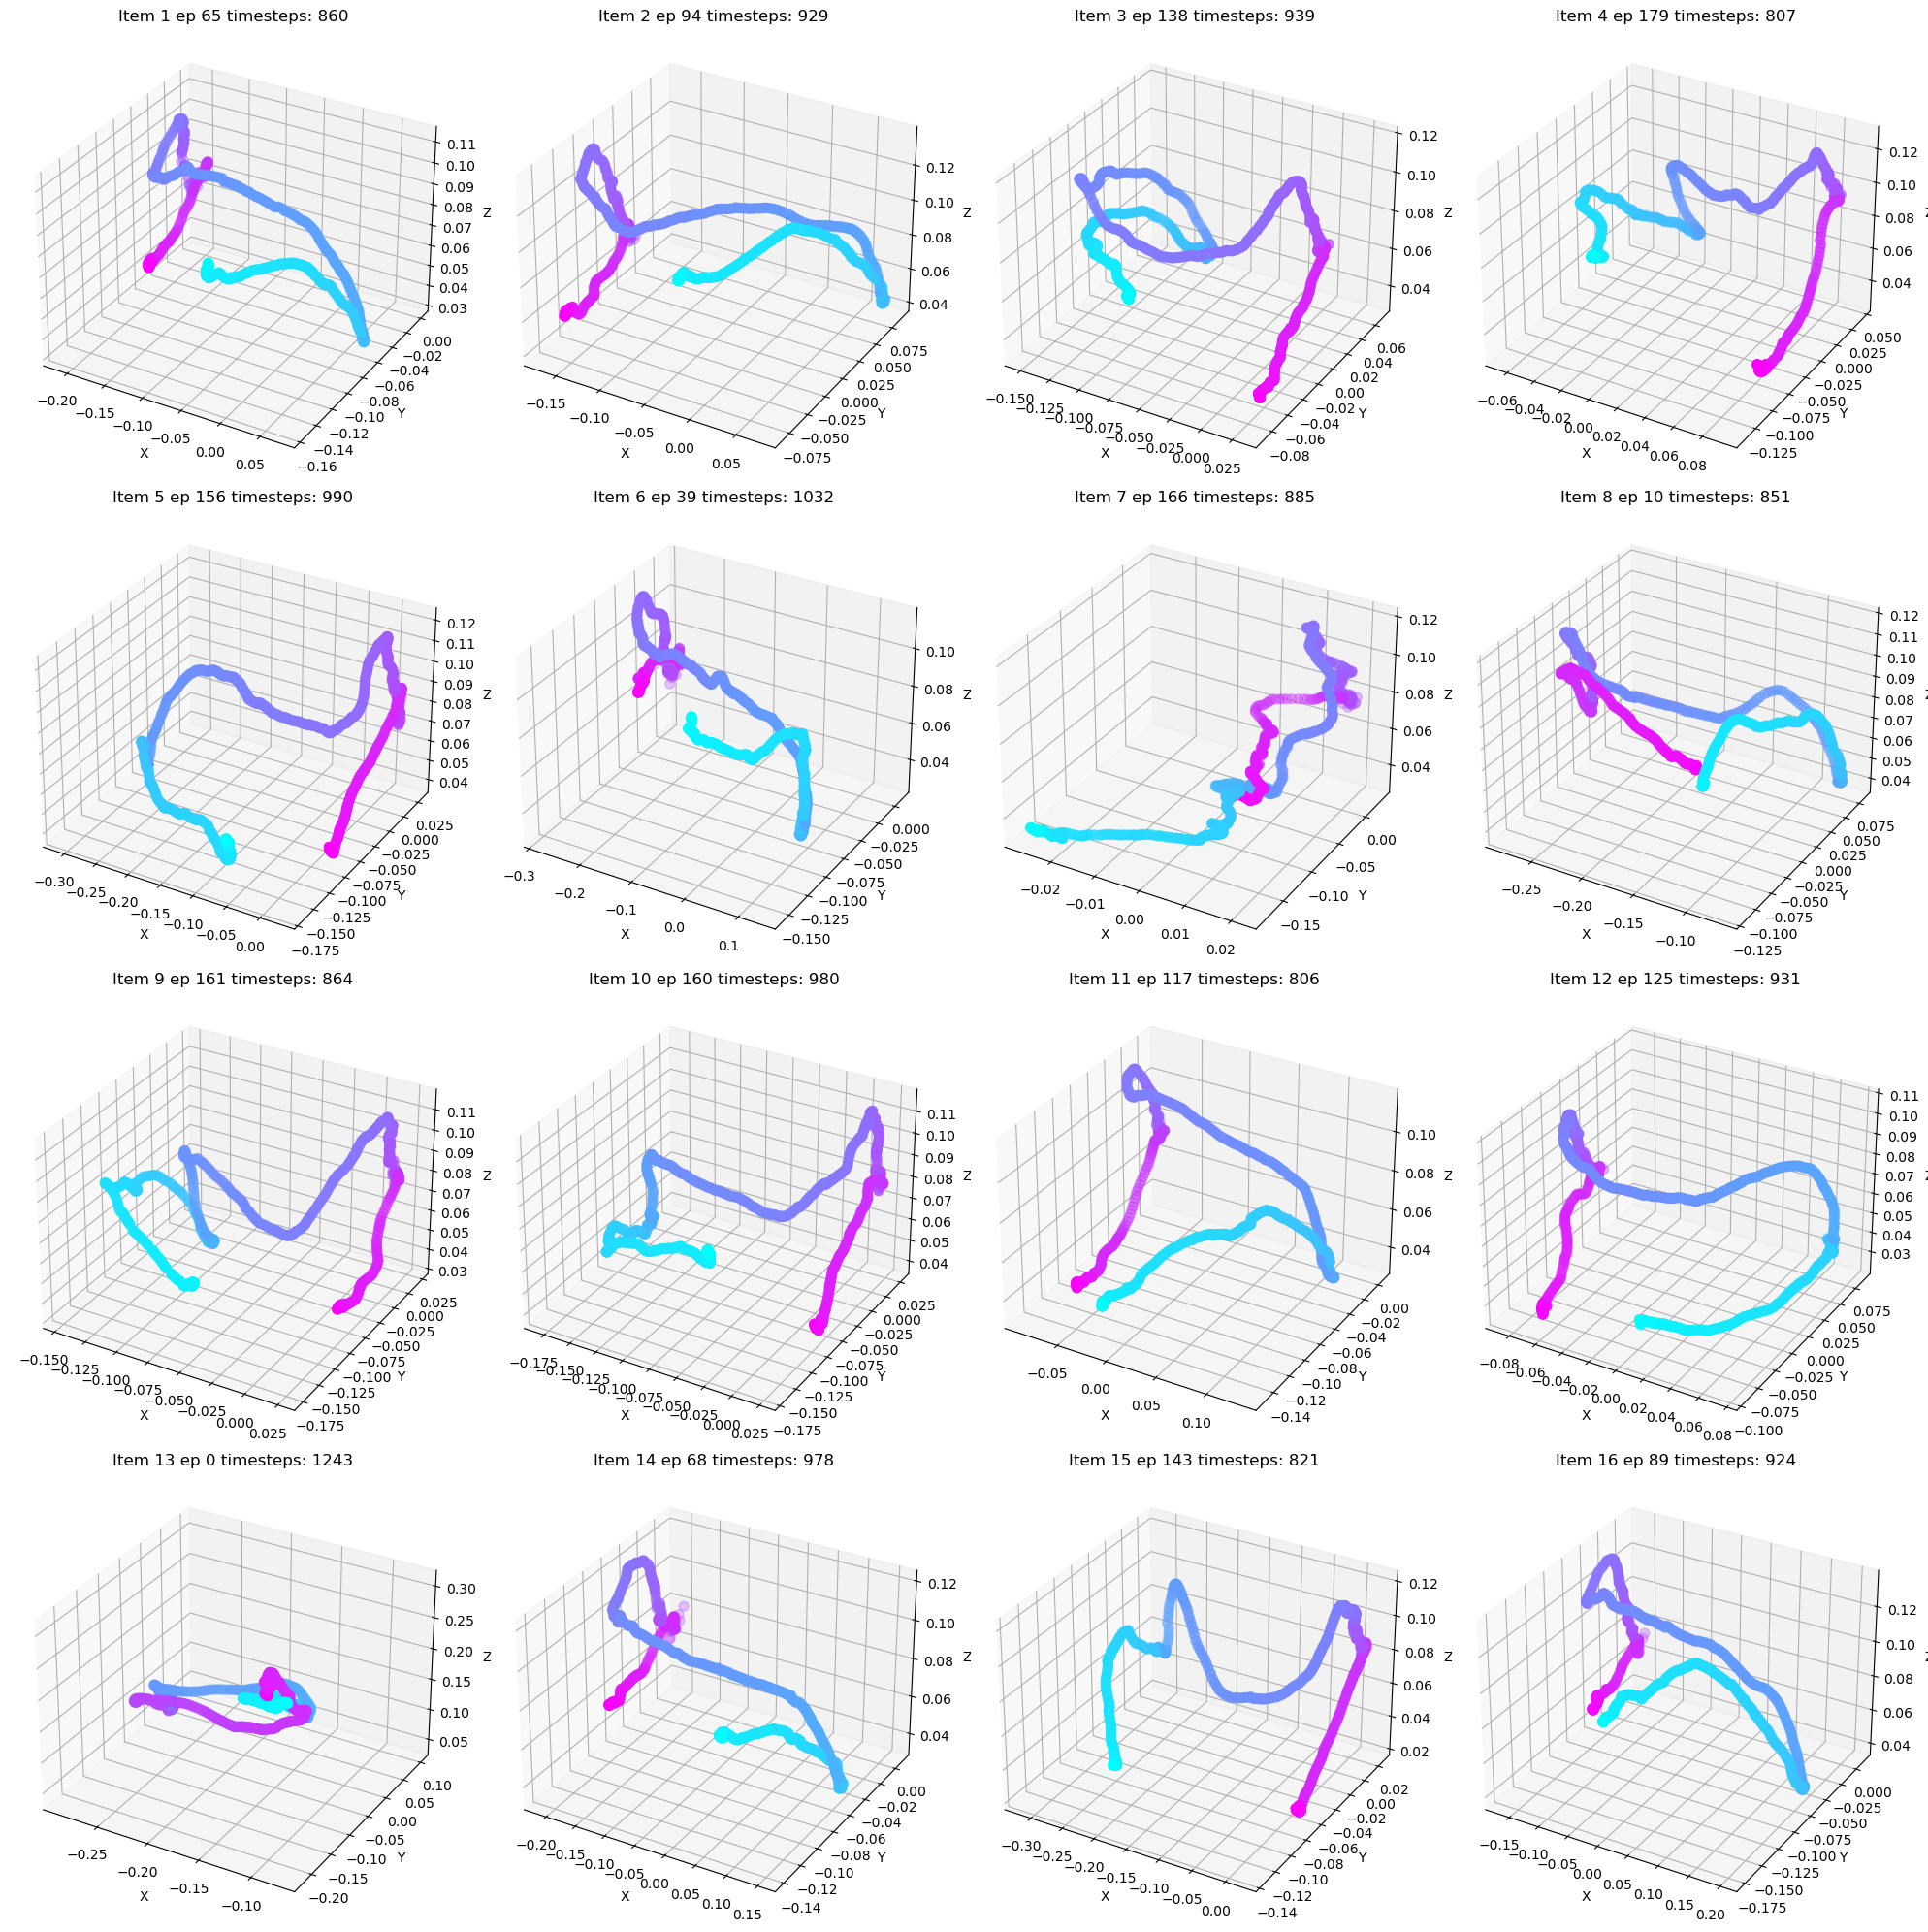

In [22]:
num_episodes = len(replay_buffer.episode_ends)
num_episodes_random = 16
random_episodes = np.random.choice(num_episodes, num_episodes_random, replace=False)
print(random_episodes)
fig = plt.figure(figsize=(20, 20))
rows = int(np.ceil(np.sqrt(num_episodes_random)))
cols = int(np.ceil(num_episodes_random / rows))
for idx, ep_idx in enumerate(random_episodes):
    episode = replay_buffer.get_episode(ep_idx)
    each_pos_replay = episode['robot0_eef_pos'][:]

    ax = fig.add_subplot(rows, cols, idx + 1, projection='3d')
    plot_pos_multi(ax, each_pos_replay, title=f"Item {idx+1} ep {ep_idx} timesteps: {len(episode['robot0_eef_pos'])}")

plt.tight_layout()
plt.show()

In [23]:
mean_start_pos_list = list()
mean_start_rot_list = list()
num_episodes = len(replay_buffer.episode_ends)

for ep_idx in range(num_episodes):
    print(ep_idx)
    episode = replay_buffer.get_episode(ep_idx)
    each_pos_replay = episode['robot0_eef_pos'][:]
    each_rot_replay = episode['robot0_eef_rot_axis_angle'][:]

    each_ep_length = len(each_pos_replay)
    start_duration = int(each_ep_length * 0.01)
    each_start_pos = episode['robot0_eef_pos'][:start_duration]
    mean_start_pos_list.append(each_start_pos)

    each_start_rot = episode['robot0_eef_rot_axis_angle'][:start_duration]
    mean_start_rot_list.append(each_start_rot)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204


In [24]:
mean_start_pos_array = np.concatenate(mean_start_pos_list, axis=0)
mean_start_rot_array = np.concatenate(mean_start_rot_list, axis=0)

In [25]:
mean_x = np.mean(mean_start_pos_array[:, 0])
mean_y = np.mean(mean_start_pos_array[:, 1])
mean_z = np.mean(mean_start_pos_array[:, 2])

mean_rx = np.mean(mean_start_rot_array[:, 0])
mean_ry = np.mean(mean_start_rot_array[:, 1])
mean_rz = np.mean(mean_start_rot_array[:, 2])


In [26]:
mean_x # -0.08782661


-0.057204604

In [27]:
mean_y # -0.13807559
# -0.13376735


-0.13520001

In [28]:
mean_z # 0.093378246
# 0.09266995


0.09353511

In [29]:
mean_rx
# -2.1256728

-2.124571

In [30]:
mean_ry
# 0.0827507


0.08234621

In [31]:
mean_rz
# 0.052626412

0.052416727

In [32]:
import time
import rtde_control
from rtde_control import RTDEControlInterface
from rtde_io import  RTDEIOInterface
from rtde_receive import RTDEReceiveInterface

In [33]:
# mean_x = 0.058042273
# mean_y = -0.13376735
# mean_z = 0.09266995
# mean_rx = -2.1256728
# mean_ry = 0.0827507
# mean_rz = 0.052626412

In [34]:
ur_ip = "192.168.3.168" 

In [35]:
rtde_c = RTDEControlInterface(ur_ip)

RuntimeError: One of the RTDE input registers are already in use! Currently you must disable the EtherNet/IP adapter, PROFINET or any MODBUS unit configured on the robot. This might change in the future.

In [75]:
rtde_r = RTDEReceiveInterface(ur_ip)

In [ ]:
rtde_r.getActualTCPPose()

In [ ]:
target_pose = [mean_x, mean_y, mean_z, mean_rx, mean_ry, mean_rz]
target_pose

In [ ]:
duration = 20.0  
lookahead_time = 0.1  
gain = 300.0
velocity = 0.5  
acceleration = 0.5

# Move using servoL
rtde_c.servoL(target_pose, velocity, acceleration, duration, lookahead_time, gain)

# Keep sending commands to maintain servoL (It requires continuous updates)
start_time = time.time()
while time.time() - start_time < duration:
    rtde_c.servoL(target_pose, velocity, acceleration, duration, lookahead_time, gain)
    time.sleep(0.008)  # Update every 8ms (recommended)


In [5]:
rtde_c.disconnect()

NameError: name 'rtde_c' is not defined